# Разведочный анализ датасета аудиозаписей скороговорок

**Цели ноутбука:**
* Провести анализ характеристик аудиофайлов (длительность, частота дискретизации, количество каналов)

* Провести анализ метаданных

* Визуализировать распределения по классам, скороговоркам, длительности

* Провести первичную предобработку

* Провести визуальный анализ

* Сделать выводы по структуре данных

Для разведочного анализа используется подготовленный датасет, состоящий из аудиозаписей детей, произносящих скороговорки (классы «хорошо» и «плохо»).

In [1]:
!pip install -q librosa soundfile numpy pandas matplotlib seaborn jupyter tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.4 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm import tqdm
import warnings
import zipfile
import gdown
from pathlib import Path
from IPython.display import Audio, display
import hashlib
from collections import defaultdict
warnings.filterwarnings('ignore')

## Загрузка датасета

In [3]:
FILE_ID = "1rDkmjV5MNcOA-dfEjB7gm7Tt0eBA_Nps"
ZIP_PATH = "dataset.zip"
EXTRACT_PATH = "data"
try:
    gdown.download(
        id=FILE_ID,
        output=ZIP_PATH,
        quiet=False,
        fuzzy=True
    )
    print("Загрузка архива завершена!")
except Exception as e:
    print(f"Ошибка при загрузке: {e}")

Downloading...
From (original): https://drive.google.com/uc?id=1rDkmjV5MNcOA-dfEjB7gm7Tt0eBA_Nps
From (redirected): https://drive.google.com/uc?id=1rDkmjV5MNcOA-dfEjB7gm7Tt0eBA_Nps&confirm=t&uuid=c2a6477d-eb6c-4cd0-abd0-38d3132f13b5
To: /content/dataset.zip
100%|██████████| 695M/695M [00:11<00:00, 59.5MB/s]

Загрузка архива завершена!


In [4]:
if os.path.exists(ZIP_PATH):
    print("Распаковка архива")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)

Распаковка архива


In [5]:
if os.path.exists(f"{EXTRACT_PATH}/хорошо") and os.path.exists(f"{EXTRACT_PATH}/плохо"):
    good_count = len(os.listdir(f"{EXTRACT_PATH}/хорошо"))
    bad_count = len(os.listdir(f"{EXTRACT_PATH}/плохо"))
    print(f"В папке хорошо файлов: {good_count}")
    print(f"В папке плохо файлов: {bad_count}")
    print(f"Общее количество записей: {good_count + bad_count}")

В папке хорошо файлов: 1875
В папке плохо файлов: 905
Общее количество записей: 2780


## Сбор информации об аудиофайлах

In [6]:
def get_audio_metadata(file_path):
    try:
        info = sf.info(file_path)
        duration = info.duration
        samplerate = info.samplerate
        channels = info.channels
        return duration, samplerate, channels
    except:
        return None, None, None


data_rows = []
for label_name, label_value in [("хорошо", 0), ("плохо", 1)]:
    folder = f"data/{label_name}"
    if not os.path.exists(folder):
        continue
    for f in tqdm(os.listdir(folder)):
        if not f.endswith('.wav'):
            continue
        path = os.path.join(folder, f)
        duration, sr, channels = get_audio_metadata(path)
        if '__' in f:
            twister = f.split('__')[1].replace('.wav', '')
        else:
            twister = 'unknown'
        data_rows.append([path, label_value, f, twister, duration, sr, channels])

df = pd.DataFrame(data_rows, columns=['path', 'label', 'filename', 'twister', 'duration', 'sample_rate', 'channels'])

100%|██████████| 905/905 [00:00<00:00, 9646.10it/s]


In [7]:
df

,path,label,filename,twister,duration,sample_rate,channels
0,data/хорошо/eu.4feaa83c-dd68-4a69-9d13-db1ae1b...,0,eu.4feaa83c-dd68-4a69-9d13-db1ae1b3a270__тлщ.wav,тлщ,7.500000,16000,1
1,data/хорошо/eu.5e2b58f0-8b68-4a53-a65c-9ec7441...,0,eu.5e2b58f0-8b68-4a53-a65c-9ec74416abe9__срл.wav,срл,5.820000,16000,1
2,data/хорошо/eu.63784c86-1d20-4bfa-aee4-5a77a9c...,0,eu.63784c86-1d20-4bfa-aee4-5a77a9cdf458__трл.wav,трл,9.500000,16000,1
3,data/хорошо/eu.d006f83b-a3a1-4a63-83fc-0e2fbe0...,0,eu.d006f83b-a3a1-4a63-83fc-0e2fbe0273be__трлш.wav,трлш,16.940000,16000,1
4,data/хорошо/eu.f31a3a75-aba9-4a45-bdd7-8a6c592...,0,eu.f31a3a75-aba9-4a45-bdd7-8a6c592d49b4__стрл.wav,стрл,9.640000,16000,1
...,...,...,...,...,...,...,...
2775,data/плохо/eu.7eeb191c-2c31-48cf-9487-a1bf63c2...,1,eu.7eeb191c-2c31-48cf-9487-a1bf63c2a033__срл.wav,срл,16.080000,16000,1
2776,data/плохо/eu.851a6d96-3dfd-40fc-986a-5a110917...,1,eu.851a6d96-3dfd-40fc-986a-5a1109174633__тл.wav,тл,12.640000,16000,1
2777,data/плохо/eu.c81f65c4-7e6e-49ed-8e21-559a4d8d...,1,eu.c81f65c4-7e6e-49ed-8e21-559a4d8d4d47__стрлш...,стрлш,25.355812,16000,1
2778,data/плохо/eu.7163b349-3aa2-45fb-ac80-2091f719...,1,eu.7163b349-3aa2-45fb-ac80-2091f7192d1e__чстрл...,чстрл,26.666313,16000,1


Примеры аудиозаписей

In [8]:
good_example_path = df[(df['twister'] == "рл") & (df['label'] == 0)]['path'].iloc[0]
bad_example_path = df[(df['twister'] == "рл") & (df['label'] == 1)]['path'].iloc[0]
good_twister = df[df['path'] == good_example_path]['twister'].iloc[0]
bad_twister = df[df['path'] == bad_example_path]['twister'].iloc[0]

Без дефектов скороговорка типа "рл"

In [9]:
print(f"Файл: {os.path.basename(good_example_path)}")
display(Audio(good_example_path))

Файл: eu.194eb2df-7b1c-45c2-b21c-99ffc756cdd2__рл.wav


С дефектом скороговорка типа "рл"

In [10]:
print(f"Файл: {os.path.basename(bad_example_path)}")
display(Audio(bad_example_path))

Файл: eu.463043b8-3651-49d2-aa66-41fe1ff3f664__рл.wav


Проверка на дубликаты

In [11]:
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

all_files = []
for root, dirs, files in os.walk("data"):
    for f in files:
        if f.endswith('.wav'):
            all_files.append(os.path.join(root, f))

hashes = defaultdict(list)
for f in all_files:
    hashes[get_hash(f)].append(f)

duplicates = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Дубликаты: {sum(len(v)-1 for v in duplicates.values())}")

Дубликаты: 0


In [12]:
print("Распределение по классам:")
df['label'].value_counts()

Распределение по классам:


,count
label,
0,1875
1,905


In [ ]:
print(f"Уникальных типов скороговорок: {df['twister'].nunique()}")

Уникальных типов скороговорок: 42


## Анализ характеристик аудио

Вычислим среднюю, медианную, минимальную и максимальную длительность.

In [ ]:
print("Статистика длительности:")
df['duration'].describe()

Статистика длительности:


,duration
count,2780.000000
mean,10.348440
std,5.966511
min,0.529563
25%,6.480000
50%,8.830000
75%,12.360000
max,68.660000


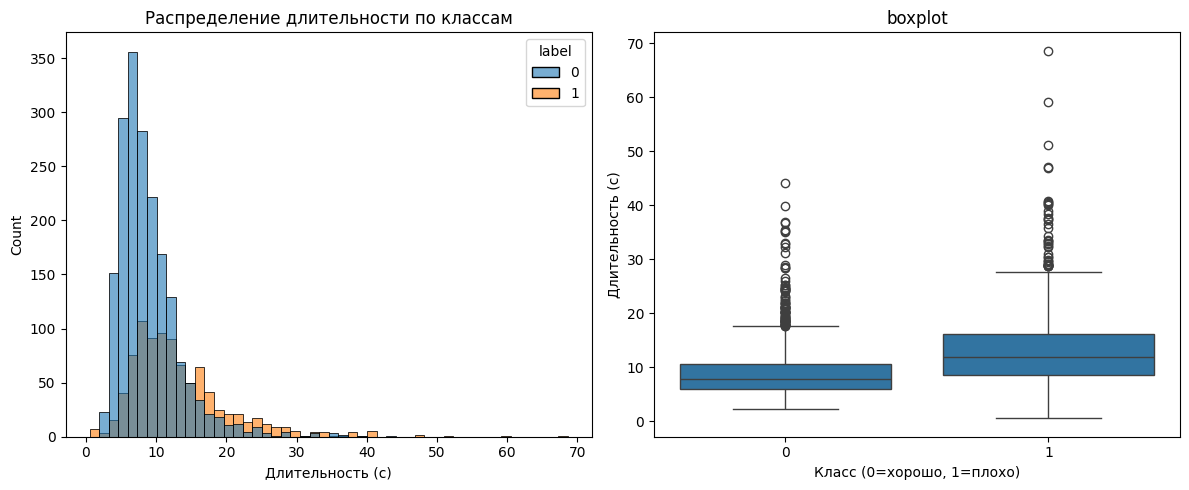

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='duration', hue='label', bins=50, alpha=0.6)
plt.title('Распределение длительности по классам')
plt.xlabel('Длительность (с)')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='label', y='duration')
plt.title('boxplot')
plt.xlabel('Класс (0=хорошо, 1=плохо)')
plt.ylabel('Длительность (с)')
plt.tight_layout()
plt.show()

In [ ]:
print("Уникальные частоты дискретизации:")
df['sample_rate'].value_counts()

Уникальные частоты дискретизации:


,count
sample_rate,
16000,2780


In [ ]:
print("Распределение по каналам:")
df['channels'].value_counts()

Распределение по каналам:


,count
channels,
1,2780


Все файлы имеют частоту 16 кГц и моно – идеально для обработки. По статистики длительности скороговорок можно увидеть, что минимальная длительность равняется около 0.53 с. Есть подозрение на наличие выбросов - шумовых записей. Поэтому следующий шаг - проверить выбросы

## Проверка на выбросы

Проверим все файлы короче 2 сек по длительности. Если они пустые, то исключим

In [ ]:
short_files = df[df['duration'] < 2]
print(f"Файлов короче 2 с: {len(short_files)} записей")
if len(short_files) > 0:
    for idx, row in short_files.iterrows():
        print(f"\n")
        print(f"Файл: {row['filename']}")
        print(f"Длительность: {row['duration']:.2f} с")
        print(f"Класс: {'хорошо' if row['label']==0 else 'плохо'}")
        print(f"Скороговорка: {row['twister']}")
        display(Audio(row['path']))

Файлов короче 2 с: 7 записей


Файл: eu.fc014530-281f-48a6-a8ed-90663a484f1a__трш.wav
Длительность: 0.75 с
Класс: плохо
Скороговорка: трш




Файл: eu.27f03007-3b1e-4f98-9335-2cb45eb4f0d0__стлц.wav
Длительность: 0.93 с
Класс: плохо
Скороговорка: стлц




Файл: eu.904117a9-7971-4722-82cb-a2b9df69cd44__чсрлц.wav
Длительность: 0.53 с
Класс: плохо
Скороговорка: чсрлц




Файл: eu.8c6aad07-02a0-43e4-9762-2242ab7ba305__трщ.wav
Длительность: 0.99 с
Класс: плохо
Скороговорка: трщ




Файл: eu.5d0a9ee2-f0c7-4f3c-9b13-b661331b2695__рлш.wav
Длительность: 1.25 с
Класс: плохо
Скороговорка: рлш




Файл: eu.4fd8801a-d7cb-41f6-9080-5a55b4097121__трл.wav
Длительность: 1.40 с
Класс: плохо
Скороговорка: трл




Файл: eu.933eed1a-8629-47bc-8304-7ec5ca65e6a2__стрл.wav
Длительность: 0.89 с
Класс: плохо
Скороговорка: стрл


Прослушав все записи, сделан вывод, что все найденные файлы в количестве 7 штук являются выбросами. Набор данных был очищен от них на данном этапе. Все дальнейшие этапы проводятся на очищенном наборе

## Локальное удаление выбросов и повторная статистика

In [ ]:
df_clean = df[df['duration'] >= 2].copy()

In [ ]:
print("Распределение по классам:")
df_clean['label'].value_counts()

Распределение по классам:


,count
label,
0,1875
1,898


Видно, что классы не сбалансированы. В дальнейшем будет применяться взвешивание и оценка модели будет по f1 - метрике.

In [ ]:
print("Статистика длительности после удаления выбросов:")
df_clean['duration'].describe()

Статистика длительности после удаления выбросов:


,duration
count,2773.000000
mean,10.372133
std,5.955329
min,2.280000
25%,6.500000
50%,8.860000
75%,12.380000
max,68.660000


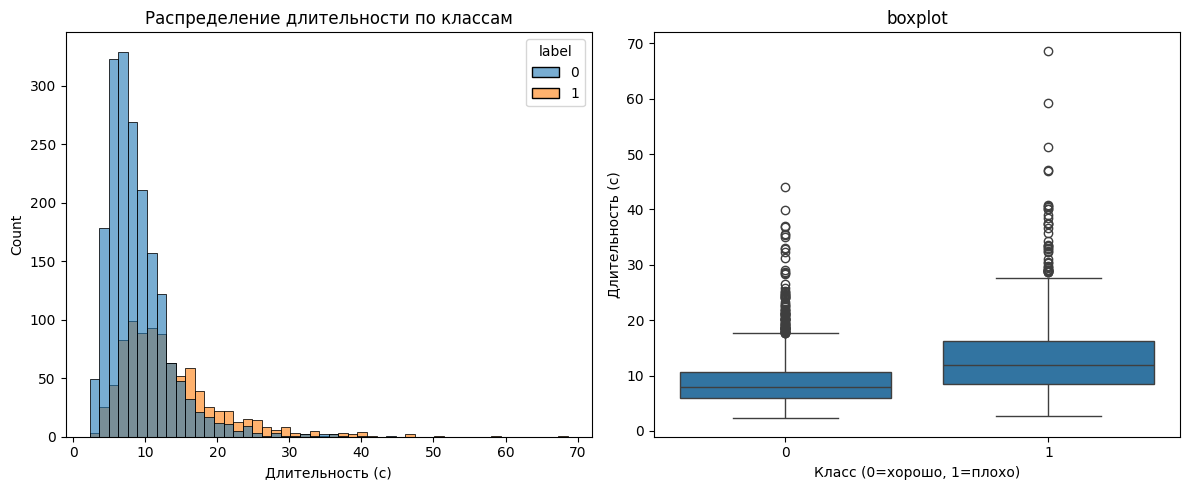

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df_clean, x='duration', hue='label', bins=50, alpha=0.6)
plt.title('Распределение длительности по классам')
plt.xlabel('Длительность (с)')

plt.subplot(1,2,2)
sns.boxplot(data=df_clean, x='label', y='duration')
plt.title('boxplot')
plt.xlabel('Класс (0=хорошо, 1=плохо)')
plt.ylabel('Длительность (с)')
plt.tight_layout()
plt.show()

## Анализ метаданных (скороговорки)

Из названий файлов уже извлекли тип скороговорки. Проанализируем, какие скороговорки встречаются чаще, какова доля дефектов в каждой группе.

In [ ]:
twister_stats = df_clean.groupby('twister').agg(
    total=('label', 'count'),
    bad=('label', 'sum')
).reset_index()
twister_stats['good'] = twister_stats['total'] - twister_stats['bad']
twister_stats['bad_ratio'] = twister_stats['bad'] / twister_stats['total']
twister_stats = twister_stats.sort_values('total', ascending=False)
twister_stats.head()

,twister,total,bad,good,bad_ratio
22,трл,295,115,180,0.389831
14,стрл,215,93,122,0.432558
18,стрш,156,49,107,0.314103
13,стр,131,44,87,0.335878
11,стлш,130,41,89,0.315385


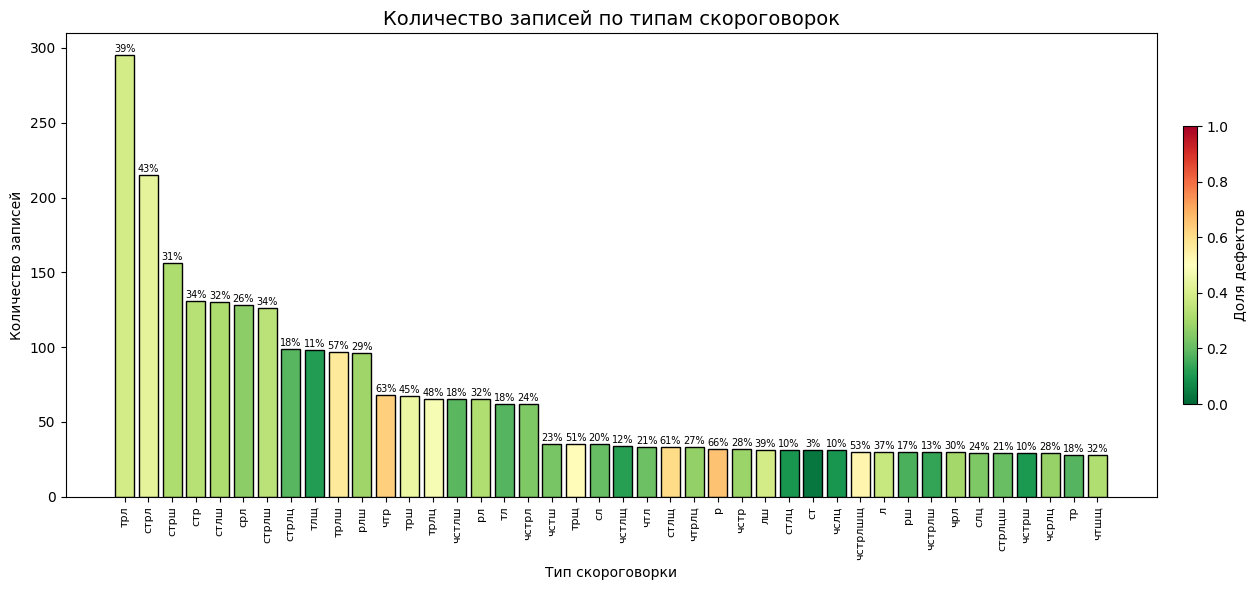

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
twister_stats_sorted = twister_stats.sort_values('total', ascending=False).copy()
colors = plt.cm.RdYlGn_r(twister_stats_sorted['bad_ratio'])
bars = ax.bar(twister_stats_sorted['twister'], twister_stats_sorted['total'], color=colors, edgecolor='black')
ax.set_xticklabels(twister_stats_sorted['twister'], rotation=90, fontsize=8)
ax.set_xlabel('Тип скороговорки')
ax.set_ylabel('Количество записей')
ax.set_title('Количество записей по типам скороговорок', fontsize=14)
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Доля дефектов', fontsize=10)
for i, (_, row) in enumerate(twister_stats_sorted.iterrows()):
    ax.text(i, row['total'] + 2, f"{row['bad_ratio']:.0%}", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

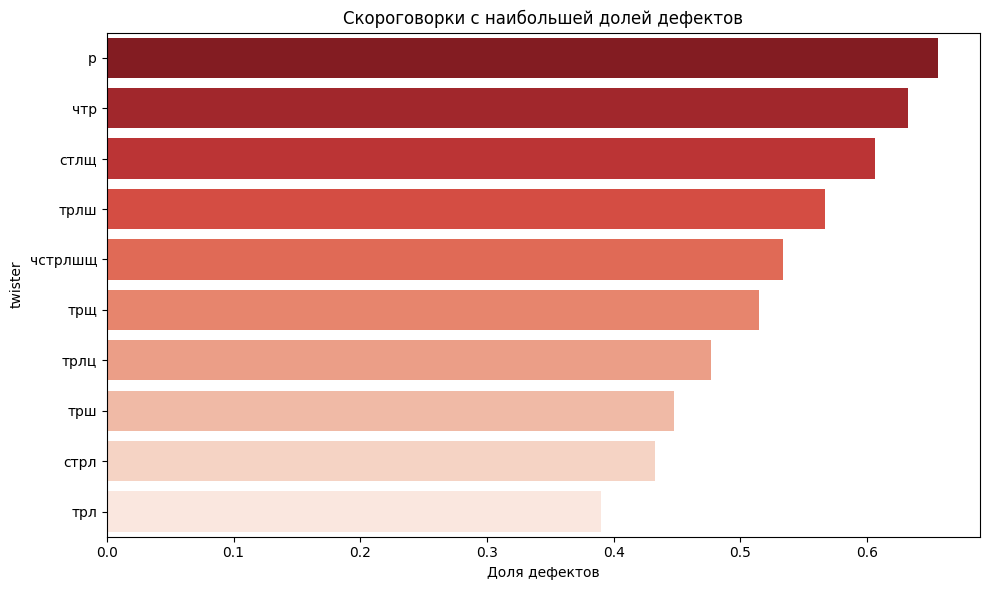

In [ ]:
twister_stats_filtered = twister_stats[twister_stats['total'] >= 5].copy()
top_bad_ratio = twister_stats_filtered.nlargest(10, 'bad_ratio')
plt.figure(figsize=(10,6))
sns.barplot(data=top_bad_ratio, y='twister', x='bad_ratio', palette='Reds_r')
plt.title('Скороговорки с наибольшей долей дефектов')
plt.xlabel('Доля дефектов')
plt.tight_layout()
plt.show()

## Визуальный анализ аудио (осциллограммы и спектрограммы)

Проанализируем два примера из самого начала

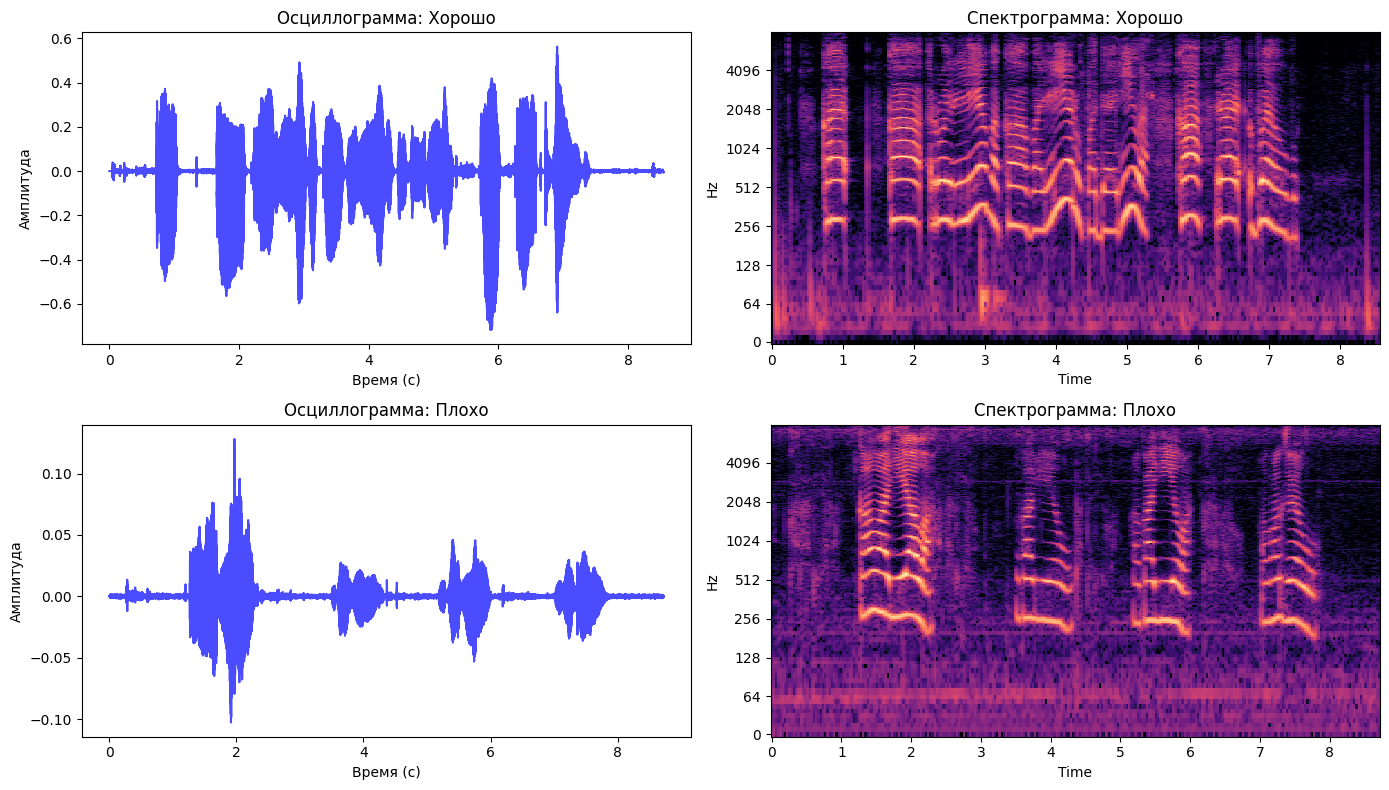

In [ ]:
def plot_waveform_and_spectrogram(file_path, title, ax_wave, ax_spec):
    y, sr = librosa.load(file_path, sr=None)
    times = np.linspace(0, len(y)/sr, num=len(y))
    ax_wave.plot(times, y, color='blue', alpha=0.7)
    ax_wave.set_xlabel('Время (с)')
    ax_wave.set_ylabel('Амплитуда')
    ax_wave.set_title(f'Осциллограмма: {title}')

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax_spec)
    ax_spec.set_title(f'Спектрограмма: {title}')
    return img

good_example = df_clean[df_clean['path'] == good_example_path].iloc[0]['path']
bad_example = df_clean[df_clean['path'] == bad_example_path].iloc[0]['path']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_waveform_and_spectrogram(good_example, 'Хорошо', axes[0,0], axes[0,1])
plot_waveform_and_spectrogram(bad_example, 'Плохо', axes[1,0], axes[1,1])
plt.tight_layout()
plt.show()

## Выводы по EDA

Итоги разведочного анализа:

 - Количество записей: всего 2780 записей, из них 1875 хороших, 905 плохих (7 из которых выбросы).

 - Скороговорки: обнаружено 42 уникальных типов. Наиболее частые: трл, стрл, стрш. Наибольшая доля дефектов у скороговорок, содержащих звуки "р", "л", "т".

 - Длительность: средняя около 10.4 сек, медиана 8.9 сек. Диапазон от 2.3 до 68.7 секунд.

 - Частота дискретизации - 16 кГц.

 - Все файлы моно, что упрощает обработку.

 - Найдено 0 дубликатов, 7 пустых файлов, которые были исключены.

 - Визуально спектрограммы хороших и плохих записей различаются, что подтверждает возможность классификации.

Для дальнейшего обучения модели мы будем приводить все аудио к фиксированной длительности 10 секунд, данная длительность покрывает около 65% файлов без потерь и является балансом между излишней обрезкой файла и добавление тишины. Для балансировки классов применим взвешивание и будем оценивать по f1 - метрике в первую очередь.